# Modell-Notebook V3

Dieses Notebook dokumentiert das V3-Modell ueber die gespeicherten Artefakte in
`models/topk_forecaster_v3`: Metadaten, Backtest-Metriken, Feature-Importances,
Priors und Beispielrankings.

Hinweise:
- Alle Pfade werden relativ zum Projekt gefunden.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "models").exists():
            return candidate
    raise FileNotFoundError("Projektwurzel mit src/ und models/ wurde nicht gefunden.")


def locate_model_dir(base_dir: Path) -> Path:
    candidates = [
        base_dir / "models" / "topk_forecaster_v3",
        base_dir / "models" / "topk_v3",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Kein V3-Modellordner gefunden.")


BASE_DIR = find_repo_root(Path.cwd())
SRC_DIR = BASE_DIR / "src"
MODEL_DIR = locate_model_dir(BASE_DIR)

print(f"BASE_DIR : {BASE_DIR}")
print(f"MODEL_DIR: {MODEL_DIR}")


BASE_DIR : C:\Users\reneb\Desktop\crime prediction
MODEL_DIR: C:\Users\reneb\Desktop\crime prediction\models\topk_forecaster_v3


In [2]:
metadata = json.loads((MODEL_DIR / "metadata.json").read_text(encoding="utf-8"))
evaluation = json.loads((MODEL_DIR / "evaluation.json").read_text(encoding="utf-8"))
priors = json.loads((MODEL_DIR / "category_share_priors.json").read_text(encoding="utf-8"))

count_importance = pd.read_csv(MODEL_DIR / "count_feature_importance.csv", encoding="utf-8-sig")
share_importance = pd.read_csv(MODEL_DIR / "share_feature_importance.csv", encoding="utf-8-sig")
preview_absolute = pd.read_csv(MODEL_DIR / "preview_top30_absolute.csv", encoding="utf-8-sig")
preview_lift = pd.read_csv(MODEL_DIR / "preview_top30_lift.csv", encoding="utf-8-sig")
series_lookup = pd.read_csv(MODEL_DIR / "series_lookup.csv", encoding="utf-8-sig")

loaded = pd.DataFrame(
    [
        {"artifact": "metadata", "rows": 1, "cols": len(metadata)},
        {"artifact": "evaluation", "rows": len(evaluation), "cols": max(len(v) for v in evaluation.values())},
        {"artifact": "count_feature_importance", "rows": len(count_importance), "cols": count_importance.shape[1]},
        {"artifact": "share_feature_importance", "rows": len(share_importance), "cols": share_importance.shape[1]},
        {"artifact": "preview_top30_absolute", "rows": len(preview_absolute), "cols": preview_absolute.shape[1]},
        {"artifact": "preview_top30_lift", "rows": len(preview_lift), "cols": preview_lift.shape[1]},
        {"artifact": "series_lookup", "rows": len(series_lookup), "cols": series_lookup.shape[1]},
    ]
)

display(loaded)


,artifact,rows,cols
0,metadata,1,21
1,evaluation,4,6
2,count_feature_importance,16,2
3,share_feature_importance,27,2
4,preview_top30_absolute,30,11
5,preview_top30_lift,30,11
6,series_lookup,78,3


In [3]:
metadata_df = pd.DataFrame(
    [{"field": key, "value": value} for key, value in metadata.items()]
)

evaluation_rows = []
for section, metrics in evaluation.items():
    for metric_name, metric_value in metrics.items():
        evaluation_rows.append(
            {
                "section": section,
                "metric": metric_name,
                "value": metric_value,
            }
        )

evaluation_df = pd.DataFrame(evaluation_rows)

display(metadata_df)
display(evaluation_df.sort_values(["section", "metric"]))


,field,value
0,architecture,mlforecast_catboost_count_plus_catboost_share
1,frameworks,"[mlforecast, catboost]"
2,count_feature_lags,"[1, 7, 14, 28]"
3,data_start_date,2022-12-31
4,data_end_date,2026-04-18
5,train_start_date,2022-12-31
6,train_end_date,2025-08-20
7,val_start_date,2025-08-21
8,val_end_date,2026-04-18
9,n_events,6505


,section,metric,value
0,count_model,mae,0.105242
3,count_model,mean_pred,0.071028
2,count_model,mean_true,0.041813
1,count_model,poisson_deviance,0.270094
5,count_model,sum_pred,1335.191694
4,count_model,sum_true,786.000000
6,share_model,accuracy_top1,0.211196
7,share_model,accuracy_top3,0.348601
8,share_model,accuracy_top5,0.430025
9,share_model,f1_macro,0.012470


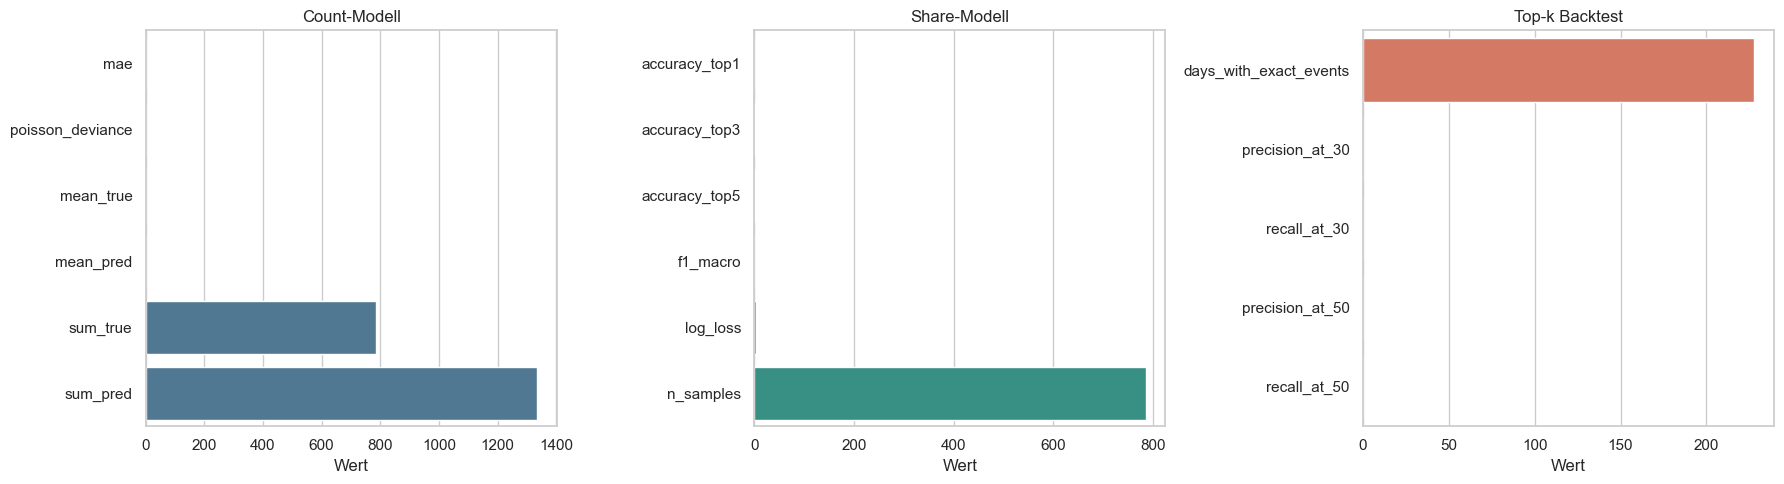

,metric,value
0,n_events,6505.000000
1,n_exact_events,5964.000000
2,exact_time_share,0.921138
3,n_valid_categories,50.000000
4,n_places,13.000000
5,n_place_bucket_series,78.000000
6,prior_weight,0.600000
7,max_lift,2.750000


In [4]:
summary_df = pd.DataFrame(
    [
        {"metric": "n_events", "value": metadata["n_events"]},
        {"metric": "n_exact_events", "value": metadata["n_exact_events"]},
        {"metric": "exact_time_share", "value": metadata["exact_time_share"]},
        {"metric": "n_valid_categories", "value": metadata["n_valid_categories"]},
        {"metric": "n_places", "value": metadata["n_places"]},
        {"metric": "n_place_bucket_series", "value": metadata["n_place_bucket_series"]},
        {"metric": "prior_weight", "value": metadata["prior_weight"]},
        {"metric": "max_lift", "value": metadata["max_lift"]},
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

count_metrics = evaluation_df.loc[evaluation_df["section"] == "count_model"]
share_metrics = evaluation_df.loc[evaluation_df["section"] == "share_model"]
ranking_metrics = evaluation_df.loc[evaluation_df["section"] == "topk_backtest"]

sns.barplot(ax=axes[0], data=count_metrics, x="value", y="metric", color="#457b9d")
axes[0].set_title("Count-Modell")
axes[0].set_xlabel("Wert")
axes[0].set_ylabel("")

sns.barplot(ax=axes[1], data=share_metrics, x="value", y="metric", color="#2a9d8f")
axes[1].set_title("Share-Modell")
axes[1].set_xlabel("Wert")
axes[1].set_ylabel("")

sns.barplot(ax=axes[2], data=ranking_metrics, x="value", y="metric", color="#e76f51")
axes[2].set_title("Top-k Backtest")
axes[2].set_xlabel("Wert")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

display(summary_df)


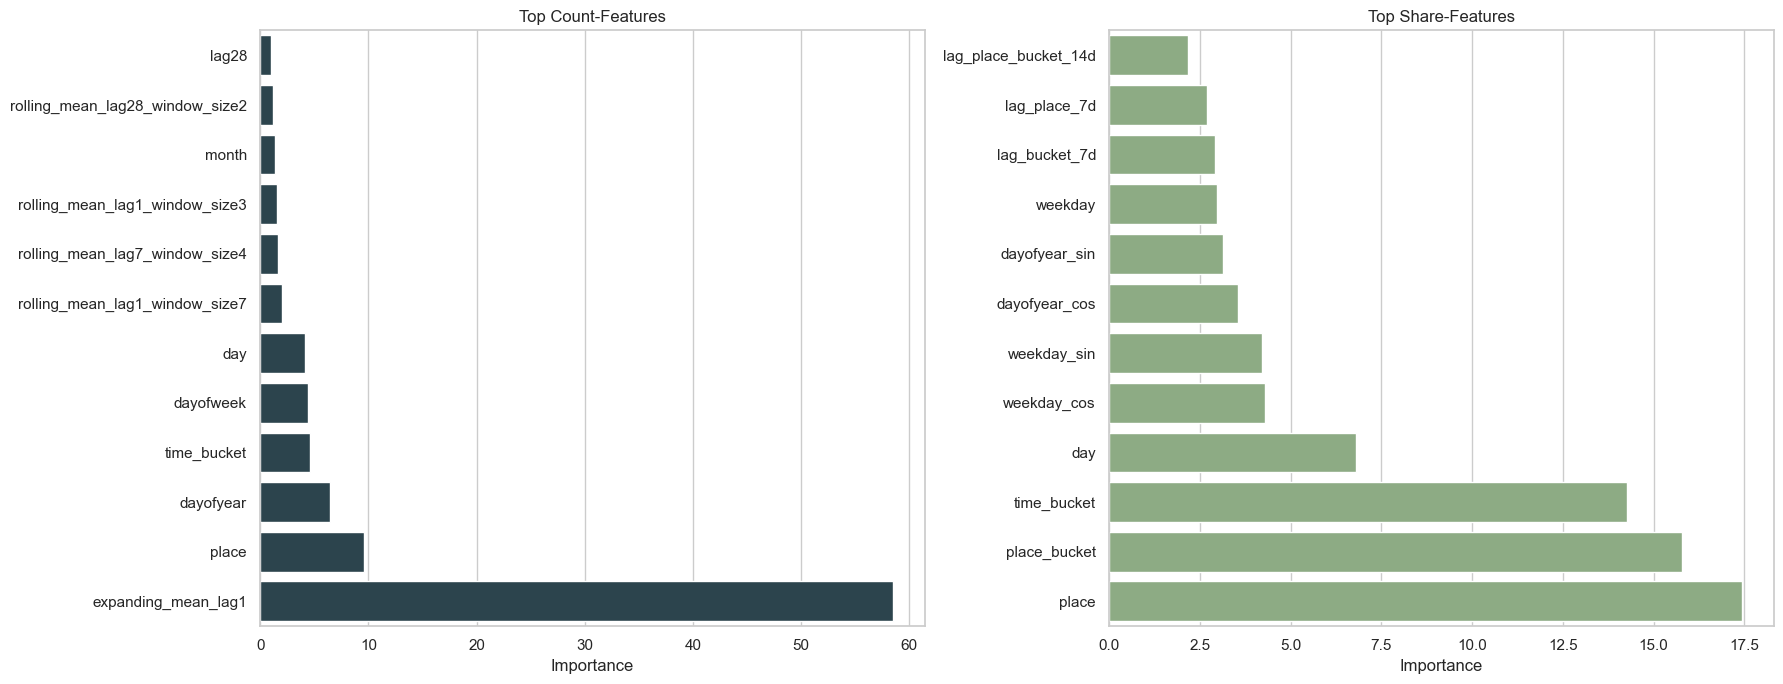

,feature,importance
0,expanding_mean_lag1,58.533002
1,place,9.566348
2,dayofyear,6.459684
3,time_bucket,4.650045
4,dayofweek,4.441014
5,day,4.130995
6,rolling_mean_lag1_window_size7,1.997084
7,rolling_mean_lag7_window_size4,1.660593
8,rolling_mean_lag1_window_size3,1.556459
9,month,1.343703


,feature,importance
0,place,17.442549
1,place_bucket,15.777665
2,time_bucket,14.251368
3,day,6.792211
4,weekday_cos,4.286016
5,weekday_sin,4.196658
6,dayofyear_cos,3.540417
7,dayofyear_sin,3.129805
8,weekday,2.982047
9,lag_bucket_7d,2.927250


In [5]:
top_count = count_importance.nlargest(12, "importance").sort_values("importance")
top_share = share_importance.nlargest(12, "importance").sort_values("importance")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(ax=axes[0], data=top_count, x="importance", y="feature", color="#264653")
axes[0].set_title("Top Count-Features")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("")

sns.barplot(ax=axes[1], data=top_share, x="importance", y="feature", color="#8ab17d")
axes[1].set_title("Top Share-Features")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(top_count.sort_values("importance", ascending=False))
display(top_share.sort_values("importance", ascending=False))


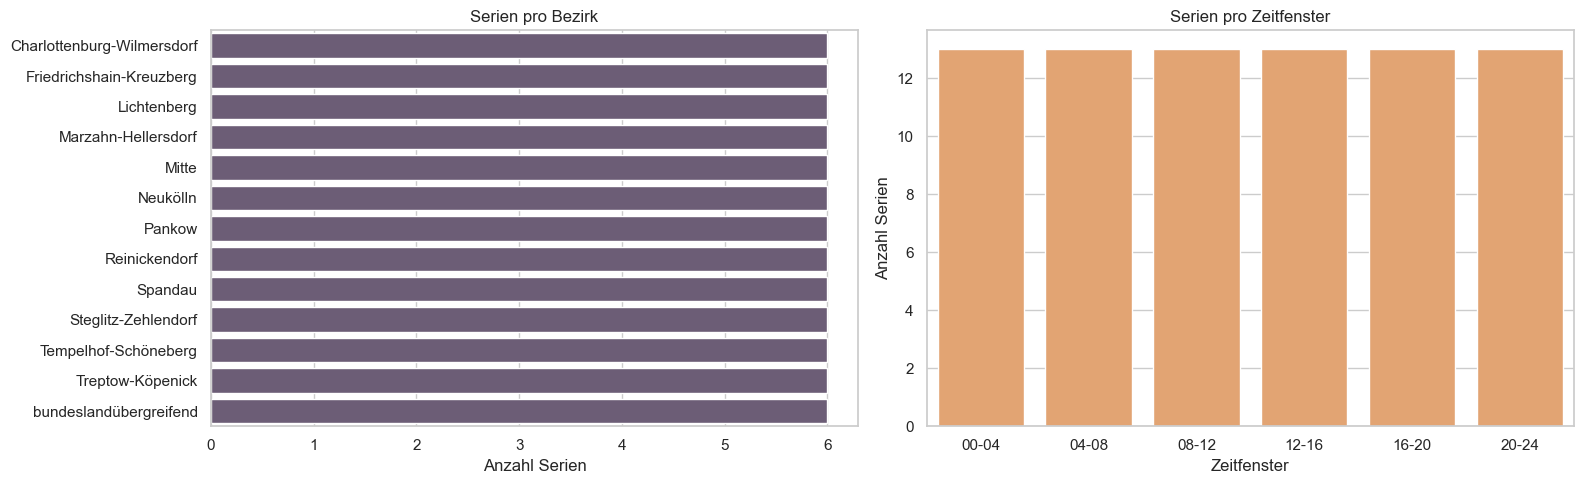

,place,series_count
0,Charlottenburg-Wilmersdorf,6
1,Friedrichshain-Kreuzberg,6
2,Lichtenberg,6
3,Marzahn-Hellersdorf,6
4,Mitte,6
5,Neukölln,6
6,Pankow,6
7,Reinickendorf,6
8,Spandau,6
9,Steglitz-Zehlendorf,6


In [6]:
series_per_place = (
    series_lookup.groupby("place", as_index=False)["unique_id"]
    .count()
    .rename(columns={"unique_id": "series_count"})
    .sort_values("series_count", ascending=False)
)

bucket_coverage = (
    series_lookup.groupby("time_bucket", as_index=False)["unique_id"]
    .count()
    .rename(columns={"unique_id": "series_count"})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(ax=axes[0], data=series_per_place, x="series_count", y="place", color="#6d597a")
axes[0].set_title("Serien pro Bezirk")
axes[0].set_xlabel("Anzahl Serien")
axes[0].set_ylabel("")

sns.barplot(ax=axes[1], data=bucket_coverage, x="time_bucket", y="series_count", color="#f4a261")
axes[1].set_title("Serien pro Zeitfenster")
axes[1].set_xlabel("Zeitfenster")
axes[1].set_ylabel("Anzahl Serien")

plt.tight_layout()
plt.show()

display(series_per_place)


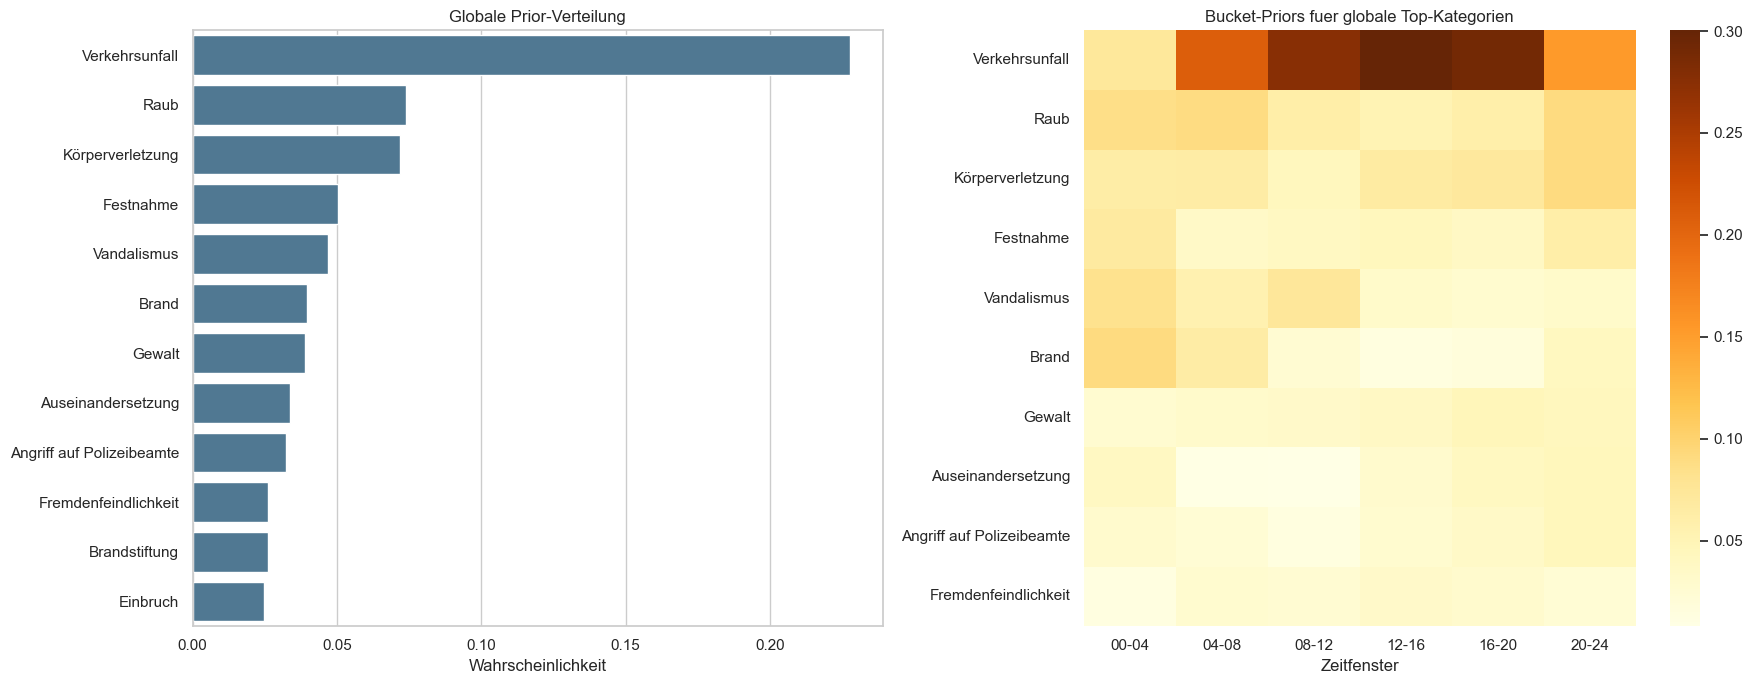

,category,probability
0,Verkehrsunfall,0.227802
1,Raub,0.073994
2,Körperverletzung,0.071999
3,Festnahme,0.050382
4,Vandalismus,0.046891
5,Brand,0.039574
6,Gewalt,0.038909
7,Auseinandersetzung,0.033921
8,Angriff auf Polizeibeamte,0.032424
9,Fremdenfeindlichkeit,0.026272


In [7]:
categories = priors["categories"]
category_to_idx = {category: idx for idx, category in enumerate(categories)}

global_prior = (
    pd.DataFrame(
        {
            "category": categories,
            "probability": priors["global"]["probs"],
        }
    )
    .sort_values("probability", ascending=False)
    .reset_index(drop=True)
)

top_global_categories = global_prior.head(10)["category"].tolist()
bucket_labels = metadata["bucket_labels"]

bucket_matrix = pd.DataFrame(
    {
        bucket_label: [
            priors["bucket"][bucket_label]["probs"][category_to_idx[category]]
            for category in top_global_categories
        ]
        for bucket_label in bucket_labels
    },
    index=top_global_categories,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(ax=axes[0], data=global_prior.head(12), x="probability", y="category", color="#457b9d")
axes[0].set_title("Globale Prior-Verteilung")
axes[0].set_xlabel("Wahrscheinlichkeit")
axes[0].set_ylabel("")

sns.heatmap(bucket_matrix, ax=axes[1], cmap="YlOrBr")
axes[1].set_title("Bucket-Priors fuer globale Top-Kategorien")
axes[1].set_xlabel("Zeitfenster")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(global_prior.head(15))


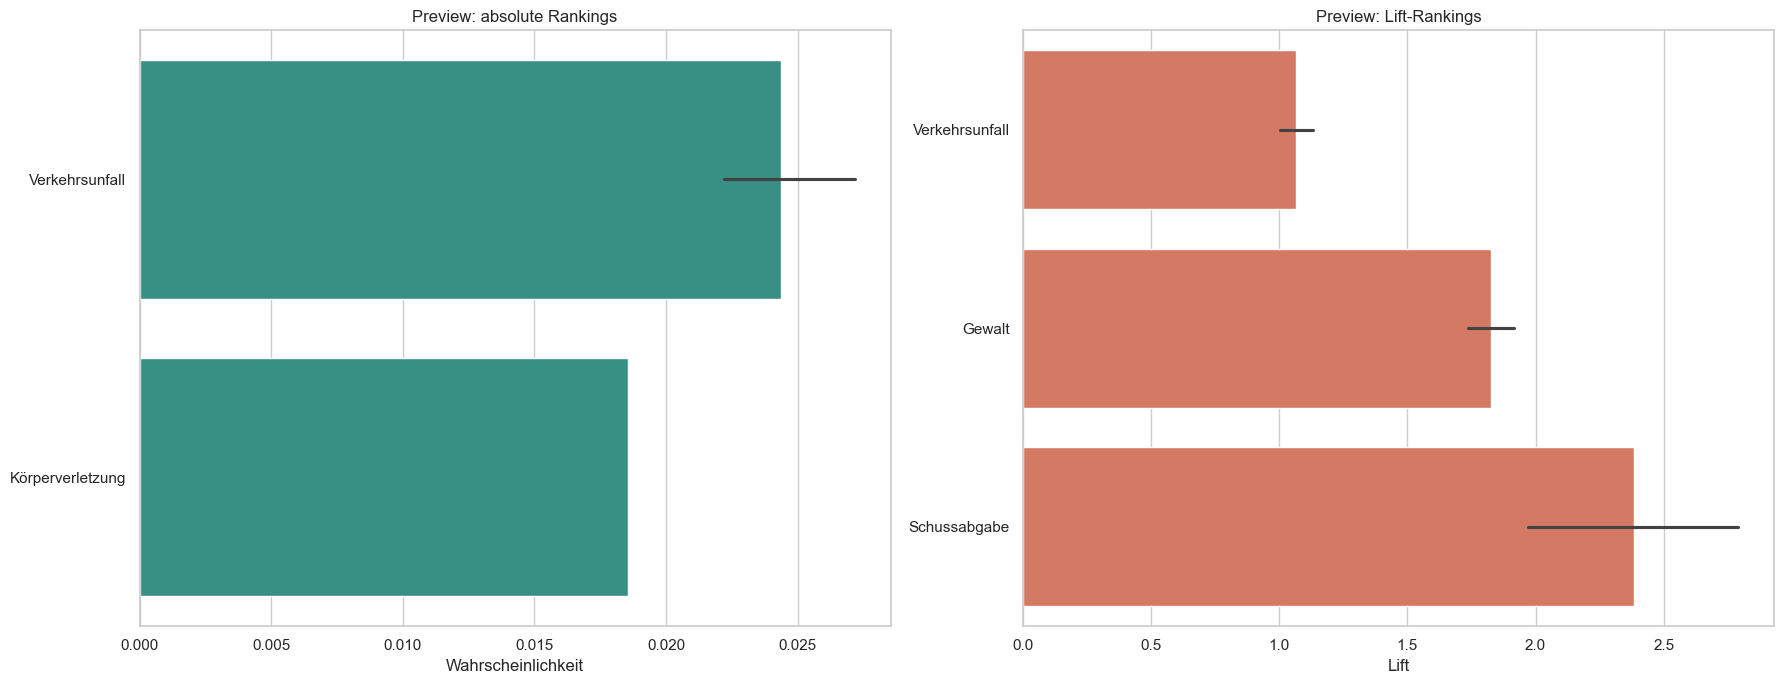

,Bezirk,Zeitfenster,Kategorie,Zellenwert,Zellenwahrscheinlichkeit,Anteil,BasisAnteil,Lift,LiftScore,Erwartet,Wahrscheinlichkeit
0,Mitte,16-20,Verkehrsunfall,0.216581,0.194733,0.173686,0.172263,1.008262,0.037223,0.037617,0.036918
1,Charlottenburg-Wilmersdorf,16-20,Verkehrsunfall,0.122839,0.115594,0.253771,0.284161,0.893055,0.027410,0.031173,0.030692
2,Charlottenburg-Wilmersdorf,12-16,Verkehrsunfall,0.113192,0.107021,0.254847,0.246270,1.034829,0.029425,0.028847,0.028435
3,Treptow-Köpenick,16-20,Verkehrsunfall,0.076767,0.073894,0.349523,0.316565,1.104112,0.029231,0.026832,0.026475
4,Mitte,12-16,Verkehrsunfall,0.145840,0.135704,0.182193,0.150810,1.208091,0.031677,0.026571,0.026221
5,Treptow-Köpenick,12-16,Verkehrsunfall,0.066643,0.064471,0.363621,0.306361,1.186905,0.028416,0.024233,0.023942
6,Pankow,16-20,Verkehrsunfall,0.096937,0.092387,0.243540,0.273458,0.890593,0.020779,0.023608,0.023332
7,Mitte,20-24,Verkehrsunfall,0.205469,0.185735,0.110951,0.128778,0.861565,0.019419,0.022797,0.022539
8,Friedrichshain-Kreuzberg,16-20,Verkehrsunfall,0.128636,0.120706,0.174745,0.163716,1.067365,0.023725,0.022478,0.022228
9,Tempelhof-Schöneberg,16-20,Verkehrsunfall,0.086968,0.083294,0.249206,0.273704,0.910493,0.019521,0.021673,0.021440


,Bezirk,Zeitfenster,Kategorie,Zellenwert,Zellenwahrscheinlichkeit,Anteil,BasisAnteil,Lift,LiftScore,Erwartet,Wahrscheinlichkeit
0,Friedrichshain-Kreuzberg,00-04,Schussabgabe,0.126819,0.119107,0.115040,0.039526,2.910532,0.042154,0.014589,0.014483
1,Mitte,16-20,Verkehrsunfall,0.216581,0.194733,0.173686,0.172263,1.008262,0.037223,0.037617,0.036918
2,Mitte,12-16,Verkehrsunfall,0.145840,0.135704,0.182193,0.150810,1.208091,0.031677,0.026571,0.026221
3,Mitte,16-20,Gewalt,0.216581,0.194733,0.080061,0.046097,1.736808,0.029856,0.017340,0.017190
4,Charlottenburg-Wilmersdorf,12-16,Verkehrsunfall,0.113192,0.107021,0.254847,0.246270,1.034829,0.029425,0.028847,0.028435
5,Neukölln,20-24,Schussabgabe,0.131385,0.123119,0.095546,0.040640,2.351046,0.029329,0.012553,0.012475
6,Treptow-Köpenick,16-20,Verkehrsunfall,0.076767,0.073894,0.349523,0.316565,1.104112,0.029231,0.026832,0.026475
7,Treptow-Köpenick,12-16,Verkehrsunfall,0.066643,0.064471,0.363621,0.306361,1.186905,0.028416,0.024233,0.023942
8,Charlottenburg-Wilmersdorf,16-20,Verkehrsunfall,0.122839,0.115594,0.253771,0.284161,0.893055,0.027410,0.031173,0.030692
9,Mitte,20-24,Gewalt,0.205469,0.185735,0.067392,0.035199,1.914591,0.026328,0.013847,0.013751


In [8]:
top_absolute = preview_absolute.head(15).copy()
top_lift = preview_lift.head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    ax=axes[0],
    data=top_absolute.sort_values("Wahrscheinlichkeit"),
    x="Wahrscheinlichkeit",
    y="Kategorie",
    color="#2a9d8f",
)
axes[0].set_title("Preview: absolute Rankings")
axes[0].set_xlabel("Wahrscheinlichkeit")
axes[0].set_ylabel("")

sns.barplot(
    ax=axes[1],
    data=top_lift.sort_values("Lift"),
    x="Lift",
    y="Kategorie",
    color="#e76f51",
)
axes[1].set_title("Preview: Lift-Rankings")
axes[1].set_xlabel("Lift")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(top_absolute)
display(top_lift)


In [9]:
sys.path.insert(0, str(SRC_DIR))

try:
    from topk_forecasting_v3 import load_topk_v3_artifacts

    artifacts = load_topk_v3_artifacts(include_data=False)
    print("Smoke test erfolgreich. Geladene Keys:")
    print(sorted(artifacts.keys()))
except Exception as exc:
    print("Optionaler Smoke Test konnte nicht ausgefuehrt werden:")
    print(exc)


Smoke test erfolgreich. Geladene Keys:
['cat_enc', 'count_forecaster', 'evaluation', 'metadata', 'priors', 'series_lookup', 'share_model']
